# Figure 3: model-based coupling

In [1]:
# import sys
# from importlib import reload
# reload(sys.modules["util.plot"])

from collections import defaultdict

import h5py

import numpy as np

# import pandas as pd
# import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

from himalaya.scoring import correlation_score, correlation_score_split
from scipy.stats import pearsonr, spearmanr

from util import plot, subject, stats
from util.path import Path
from util.atlas import Atlas, get_brainmask
from constants import SUBS_STRANGERS

# import warnings
# warnings.filterwarnings("ignore")

plt.style.use('figures.mplstyle')

In [2]:
%cd ..

/scratch/gpfs/zzada/fconv


In [3]:
modelname = "joint_split"
features = ["confounds", "stats", "acoustic", "articulatory", "LLM"]

cache = 'default_task'

FG_MASK = get_brainmask()

encmodel = f"encoding_{cache}"

cachedir = f"results/cache/figure3-mbc/{modelname}/{cache}/"
resultdir = f'figures/figure3/{encmodel}/{modelname}/{cache}'
!mkdir -p $resultdir
!mkdir -p $cachedir

modelname, encmodel, cache, cachedir

('joint_split',
 'encoding_default_task',
 'default_task',
 'results/cache/figure3-mbc/joint_split/default_task/')

In [4]:
enc_sigmask = np.load(f'results/cache/figure2-{encmodel}/joint/{cache}/sigmask.npy')

FileNotFoundError: [Errno 2] No such file or directory: 'results/cache/figure2-encoding_default_task/joint/default_task/sigmask.npy'

In [51]:
def get_mbc(modelname:str):
    mbc_scores = defaultdict(list)

    # use subA's predictions on subB's actual neural data
    for subA in tqdm(SUBS_STRANGERS):
        # load subA preds
        encpath = Path(root='results/' + encmodel, sub=f"{subA:03d}", datatype=modelname, ext=".hdf5")
        with h5py.File(encpath, "r") as f:
            cv_predsA = f["cv_preds"][:, -1]  # take just LLM
            cv_prod_mask = f["cv_prod_mask"][...]
            cv_comp_mask = f["cv_comp_mask"][...]

        # # load subB preds
        subB = subject.get_partner(subA)
        dataB = subject.get_bold(subB, cache=cache).reshape(5, 240, -1)

        encpath = Path(root='results/' + encmodel, sub=f"{subB:03d}", datatype=modelname, ext=".hdf5")
        with h5py.File(encpath, "r") as f:
            cv_predsB = f["cv_preds"][:, :]
            nuis_predsB = f["cv_preds"][:, :-1].sum(1)
        dataB = dataB - nuis_predsB

        for i in range(5):
            y_pred = cv_predsA[i]
            # y_pred = cv_predsB[i]
            # y_pred[-1] = cv_predsA[i]
            y_true = dataB[i]
            prod_mask = cv_prod_mask[i]
            comp_mask = cv_comp_mask[i]
            prod_only_mask = prod_mask & ~comp_mask
            comp_only_mask = comp_mask & ~prod_mask

            mbc_scores["prod"].append(correlation_score(y_true[prod_only_mask], y_pred[prod_only_mask]))
            mbc_scores["comp"].append(correlation_score(y_true[comp_only_mask], y_pred[comp_only_mask]))

            # mbc_scores["prod"].append(correlation_score_split(y_true[prod_only_mask], y_pred[:, prod_only_mask])[-1])
            # mbc_scores["comp"].append(correlation_score_split(y_true[comp_only_mask], y_pred[:, comp_only_mask])[-1])

    sub_mbc_prod = np.stack(mbc_scores["prod"])
    sub_mbc_comp = np.stack(mbc_scores["comp"])
    
    return sub_mbc_prod, sub_mbc_comp

In [52]:
sub_mbc_prod, sub_mbc_comp = get_mbc(modelname)
sub_mbc_prod.shape

100%|██████████| 58/58 [06:32<00:00,  6.77s/it]


(290, 81924)

In [53]:
# save
with h5py.File(f"{cachedir}/mbc.hdf5", "w") as f:
    f.create_dataset(name="prod", data=sub_mbc_prod)
    f.create_dataset(name="comp", data=sub_mbc_comp)

In [5]:
# read
with h5py.File(f"{cachedir}/mbc.hdf5", "r") as f:
    sub_mbc_prod = f["prod"][...]
    sub_mbc_comp = f["comp"][...]

In [6]:
sub_mbc = (sub_mbc_prod + sub_mbc_comp) / 2
avg_mbc = (sub_mbc_prod.mean(0) + sub_mbc_comp.mean(0)) / 2
sub_mbc.shape, avg_mbc.shape

((290, 81924), (81924,))

In [55]:
print(avg_mbc.min())
print(avg_mbc.max())

-0.030510312
0.07874648


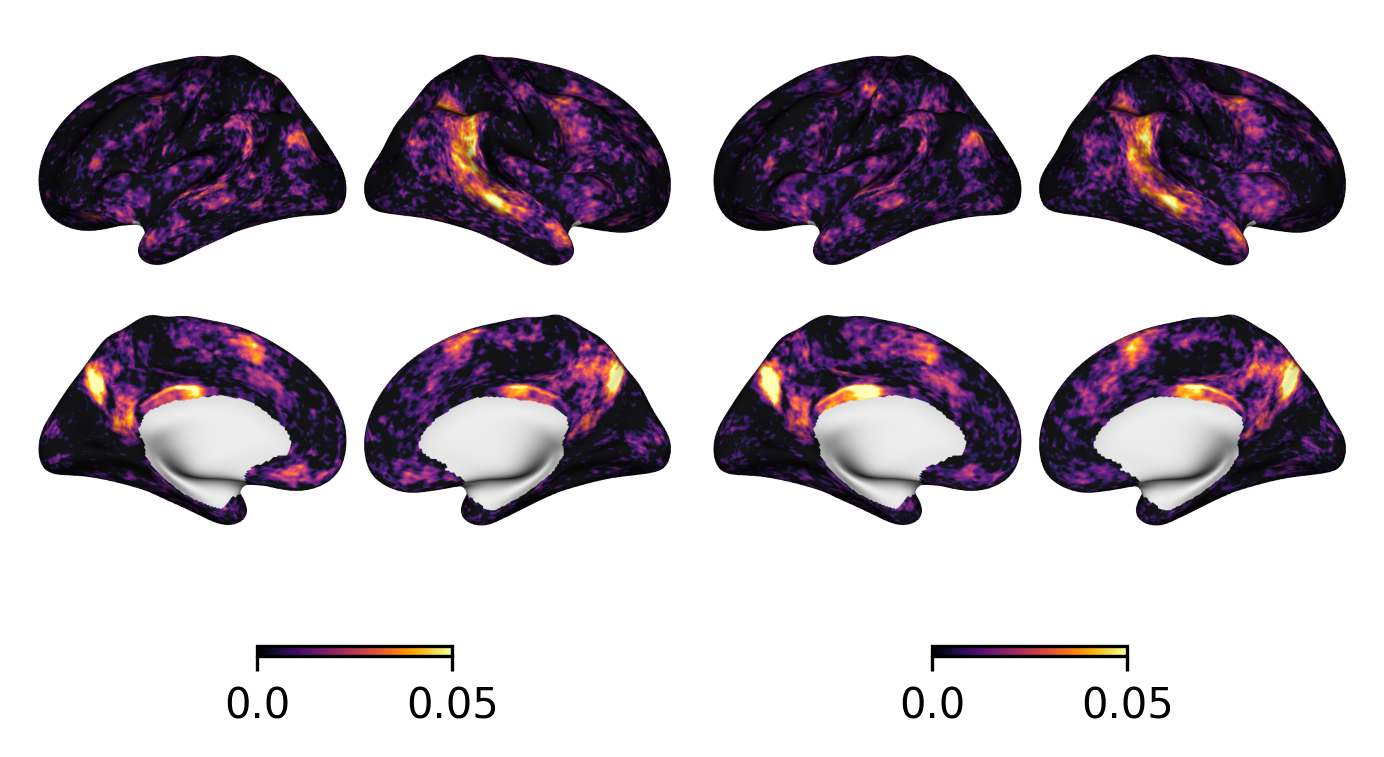

In [56]:
fig, axes = plot.two_brain_fig(layout='constrained', dpi=300)
plot.surface_plot(sub_mbc_prod.mean(0), cmap="inferno", vmin=0, vmax=0.05, fig=fig, ax=axes[0])
plot.surface_plot(sub_mbc_comp.mean(0), cmap="inferno", vmin=0, vmax=0.05, fig=fig, ax=axes[1])
fig.show()

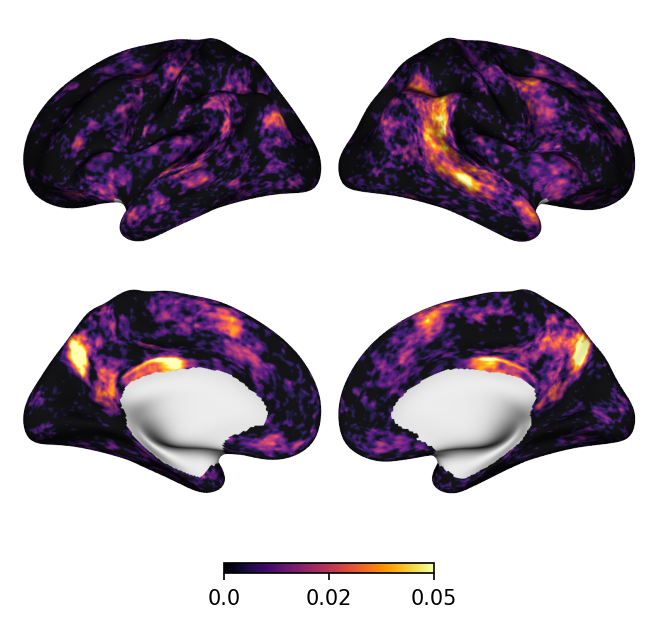

In [57]:
plot.surface_plot(avg_mbc, cmap="inferno", vmin=0, vmax=0.05);

In [58]:
sigmask = stats.ttest_1samp(sub_mbc, method='fdr_bh', alpha=0.05, alternative='greater')
sigmask.sum()

14735

In [59]:
print(avg_mbc[sigmask].min())
print(avg_mbc[sigmask].max())

0.00983566
0.07874648


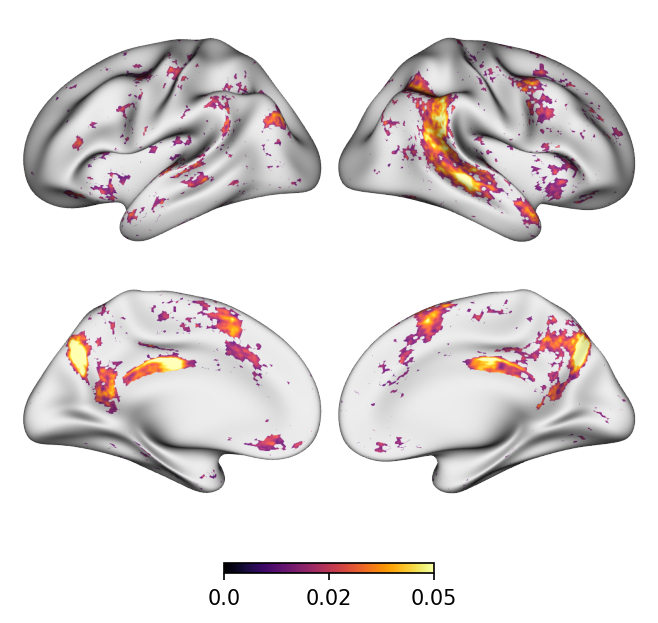

In [60]:
fig = plot.surface_plot(avg_mbc, threshold=~sigmask, cmap="inferno", vmin=0)
# fig.savefig(f'{resultdir}/mbc.svg')

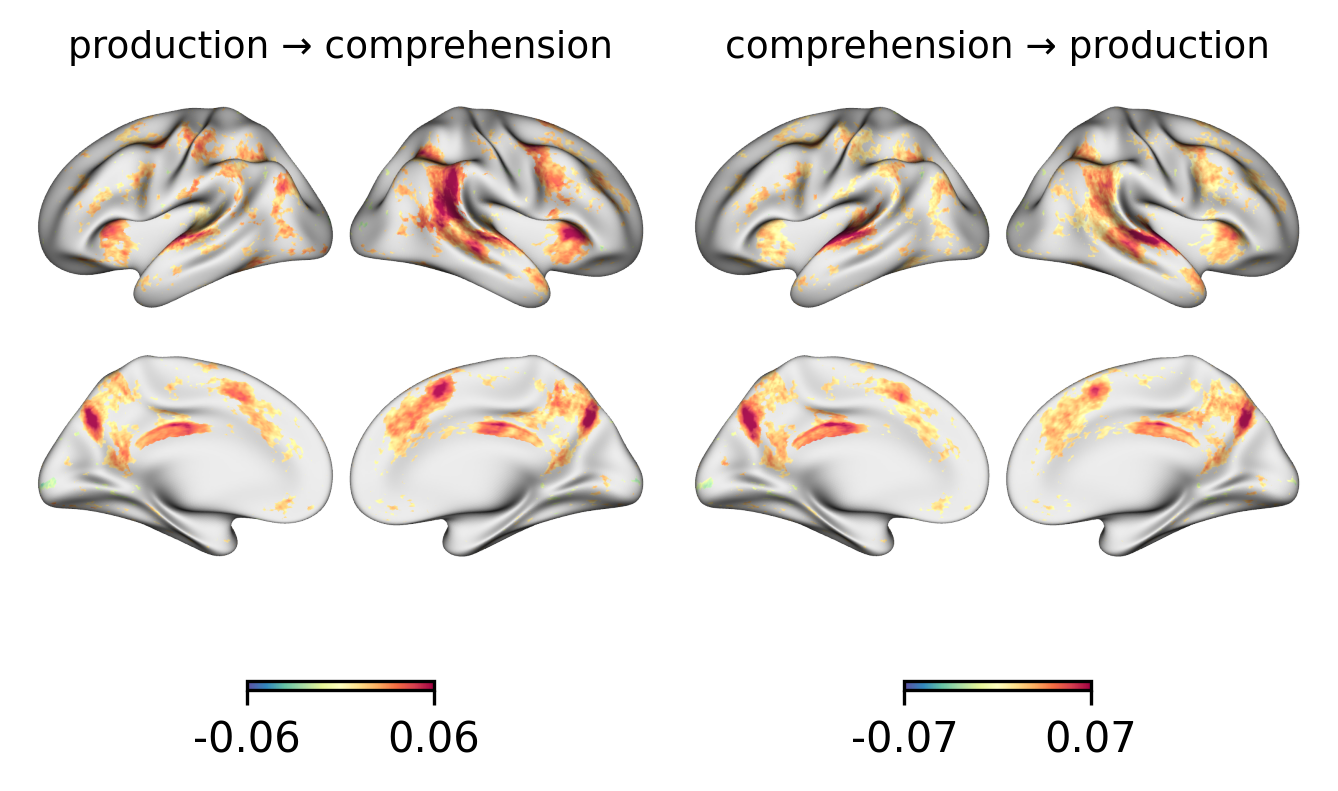

In [17]:
values1 = sub_mbc_prod.mean(0)
values2 = sub_mbc_comp.mean(0)
prod_cmap = comp_cmap = 'Spectral_r'

fig, axes = plot.two_brain_fig(layout='tight', dpi=300)
plot.surface_plot(values1, threshold=~sigmask, fig=fig, ax=axes[0], vmax=None, cmap=prod_cmap, title='production → comprehension')
plot.surface_plot(values2, threshold=~sigmask, fig=fig, ax=axes[1], vmax=None, cmap=comp_cmap, title='comprehension → production')
fig.show()

# enc scatter

In [61]:
respath = Path(
    root='results/' + encmodel,
    sub="000",
    datatype=modelname,
    ext=".hdf5",
)

results = []
results_prod = []
results_comp = []
for sub in tqdm(SUBS_STRANGERS):
    respath.update(sub=f"{sub:03d}")
    if not respath.isfile():
        print("skip", respath.fpath)
        continue
    with h5py.File(respath, "r") as f:
        prod = f['cv_scores_prod_exclusive'][:, -1] 
        comp = f['cv_scores_comp_exclusive'][:, -1]
        results.append(np.mean(prod + comp, axis=0))
        results_prod.append(prod.mean(0))
        results_comp.append(comp.mean(0))

sub_enc_perf = np.stack(results)
avg_enc_perf = sub_enc_perf.mean(0)
avg_enc_perf.shape

100%|██████████| 58/58 [00:01<00:00, 40.47it/s]


(81924,)

In [63]:
prod_scores = np.stack(results_prod).mean(0)
comp_scores = np.stack(results_comp).mean(0)
prod_scores.shape

(81924,)

## skip this

In [ ]:
values1 = prod_scores
values2 = comp_scores

vox_colors = avg_mbc

order = vox_colors.argsort()[::-1]

fig = plt.figure(figsize=(2.75, 2.75), dpi=300)
ax = fig.add_subplot()

# ax.axvline(0, c="k", zorder=1, alpha=1)
# ax.axhline(0, c="k", zorder=1, alpha=1)
ax.axline(xy1=(0, 0), slope=1, alpha=0.3, c="k", ls='dashed')

im = ax.scatter(
    values1[order], values2[order], c=vox_colors[order], s=10, alpha=0.3,
    # edgecolors='black', linewidths=0.25, marker='o',
    marker='.',
    cmap='Spectral', vmin=-.1, vmax=0.1)
ax.set_aspect("equal", "box")

lim = max(ax.get_xlim()[1], ax.get_ylim()[1])
ax.set_xlim(ax.get_xlim()[0], lim)
ax.set_ylim(ax.get_xlim()[0], lim)

ax.set_xlabel("production\nencoding performance (r)")
ax.set_ylabel("comprehension\nencoding performance (r)")

# cbar = fig.colorbar(im, shrink=0.86)
# cbar.set_label("density")

# cbar = fig.colorbar(im, ax=ax)

fig.show()

In [ ]:
# positive
mask = enc_sigmask & sigmask & (avg_mbc > 0.03)
values2 = np.ones_like(avg_mbc)
values2[~mask] = 0
plot.surface_plot(values2, cbar=False, vmin=0, cmap='Spectral', vmax=1.2);

In [ ]:
mask = enc_sigmask & (avg_mbc < .03) & sigmask
values2 = np.ones_like(avg_mbc)
values2[~mask] = 0
plot.surface_plot(values2, cbar=False, vmin=0, cmap='Spectral_r', vmax=1.2);

In [ ]:
mask = enc_sigmask & (avg_mbc < .03) & (avg_mbc > -.03)
values2 = np.ones_like(avg_mbc)
values2[~mask] = 0
plot.surface_plot(values2, cbar=False, vmin=0, vmax=2, cmap='Spectral_r');

## corr with encoding

In [65]:
corr_out = pearsonr(avg_enc_perf[FG_MASK], avg_mbc[FG_MASK])
corr_out

PearsonRResult(statistic=0.4916227185604307, pvalue=0.0)

In [66]:
with h5py.File(f"results/cache/figurex-isc/{cache}/full_isc_avg.hdf5", "r") as f:
    avg_isc = f["avg_isc"][...]
    sigmask_isc = f["sigmask"][...]

FileNotFoundError: [Errno 2] Unable to open file (unable to open file: name = 'results/cache/figurex-isc/default_task/full_isc_avg.hdf5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [16]:
pearsonr(avg_mbc, avg_isc)

PearsonRResult(statistic=0.7440386952961529, pvalue=0.0)

In [34]:
import matplotlib as mpl

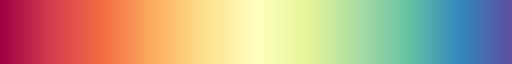

In [35]:
cm = plt.get_cmap("Spectral")
norm = mpl.colors.Normalize(vmin=-.1, vmax=.1)
cm.set_bad(color='Gray', alpha=1)
cm

In [69]:
values1 = avg_enc_perf
values2 = avg_mbc
# vox_colors = avg_isc


order = None
# order = vox_colors.argsort()#[::-1]

/tmp/ipykernel_2477415/3710293757.py:3: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin', 'vmax' will be ignored
  im = ax.scatter(


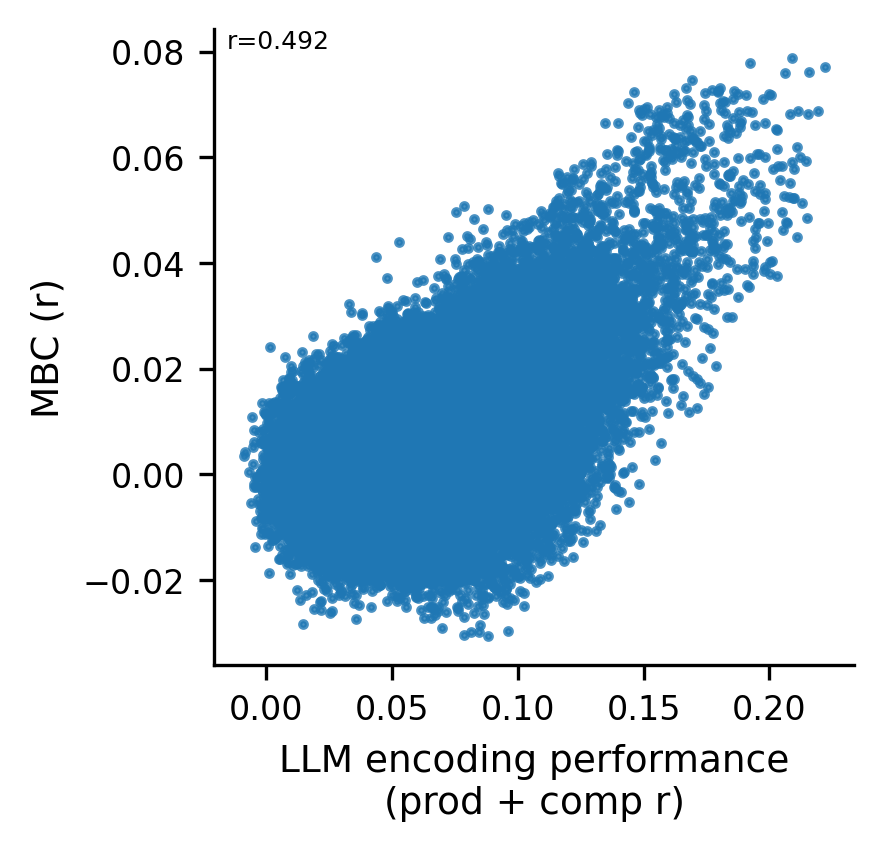

In [72]:
fig, ax = plt.subplots(figsize=(2.75, 2.75), dpi=300)

im = ax.scatter(
    values1[order], values2[order], #c=vox_colors[order],
    s=10, alpha=0.8, marker='.',
    cmap='Spectral_r', vmin=-.07, vmax=0.07)

xlim = ax.get_xlim()
ylim = ax.get_ylim()

ax.set_ylabel("MBC (r)")
ax.set_xlabel("LLM encoding performance\n(prod + comp r)")

ax.text(x=0.02, y=1, s=f"r={corr_out.statistic:0.3f}", transform=ax.transAxes,
        verticalalignment='top', horizontalalignment='left', fontsize=6)

# fig.colorbar(im, ax=ax, shrink=0.5)

# ax.set_axis_off()
# fig.savefig(f'{resultdir}/enc-mbc.png', dpi=300, bbox_inches=0)
fig.show()

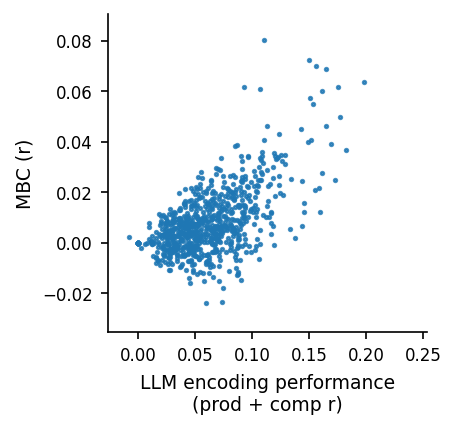

In [38]:
fig = plt.figure(figsize=(2.75, 2.75))
ax = fig.add_subplot()

im = ax.scatter(values1[order[::100]], values2[order[::100]], s=10, alpha=0.8, marker='.',)
ax.set_xlim(xlim)
ax.set_ylim(ylim)

ax.set_ylabel("MBC (r)")
ax.set_xlabel("LLM encoding performance\n(prod + comp r)")

fig.savefig(f'{resultdir}/enc-mbc.svg')
fig.show()

In [16]:
plot_params = dict(cmap="Grays", vmin=0, vmax=1, cbar=False, size=(800, 200), zoom=1.2, layout='row', mirror_views=True)

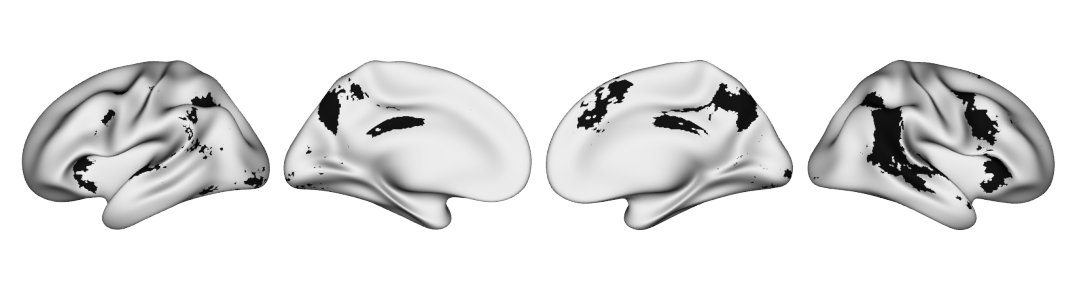

In [17]:
# positive
mask = (avg_enc_perf > .1) & (avg_mbc > .03)
values2 = np.ones_like(avg_mbc)
values2[~mask] = 0
plot.surface_plot(values2, **plot_params);

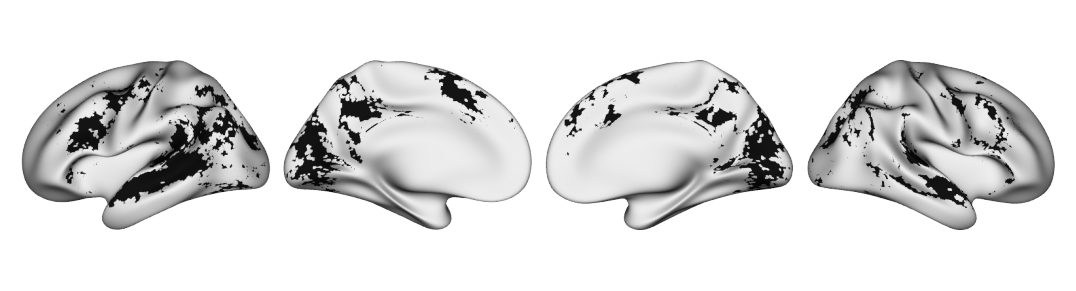

In [18]:
# within only
mask = (avg_enc_perf > .1) & (np.abs(avg_mbc) < .03)
values2 = np.ones_like(avg_mbc)
values2[~mask] = 0
plot.surface_plot(values2, **plot_params);

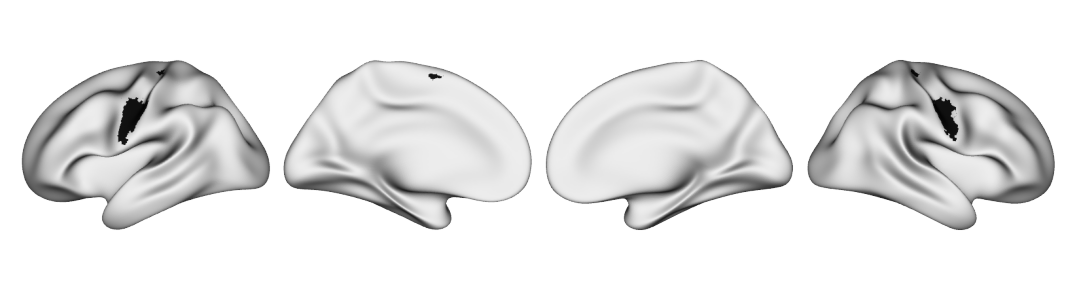

In [19]:
# negative
mask = (avg_enc_perf > .1) & (avg_mbc < -.03)
values2 = np.ones_like(avg_mbc)
values2[~mask] = 0
plot.surface_plot(values2, **plot_params);

In [103]:
prod_within = np.stack(results_prod).mean(0)
comp_within = np.stack(results_comp).mean(0)

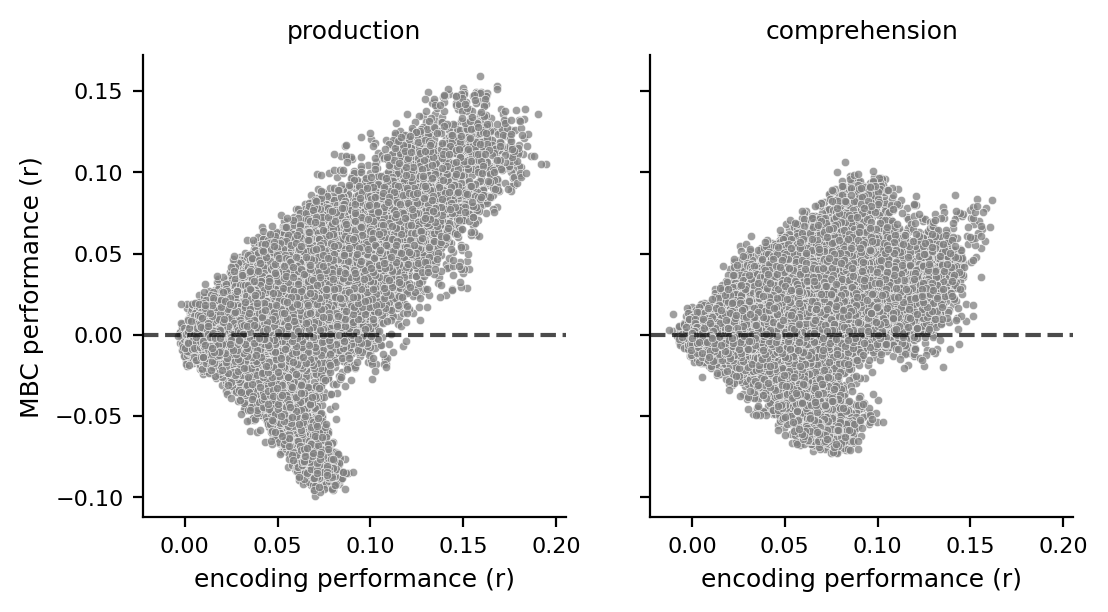

In [119]:
fig, axes = plt.subplots(1, 2, figsize=(6, 3), dpi=200, sharex=True, sharey=True)

axes[0].scatter(prod_within[FG_MASK], sub_mbc_prod.mean(0)[FG_MASK], marker='.', alpha=0.75, c='gray', edgecolors='white', linewidths=0.25)
axes[1].scatter(comp_within[FG_MASK], sub_mbc_comp.mean(0)[FG_MASK], marker='.', alpha=0.75, c='gray', edgecolors='white', linewidths=0.25)

for ax in axes:
    ax.axhline(0, c="k", zorder=1, alpha=0.7, ls='dashed')
    ax.set_xlabel("encoding performance (r)")

axes[0].set_ylabel("MBC performance (r)")

axes[0].set_title('production')
axes[1].set_title('comprehension')

fig.show()

# weight similarity

In [55]:
# sim between prod and comp
weight_sim_between = []

respath = Path(
    root='results/' + encmodel + '_n2',
    sub="000",
    datatype=modelname,
    ext=".hdf5",
)

for i, sub in enumerate(tqdm(SUBS_STRANGERS)):
    respath.update(sub=f"{sub:03d}")
    with h5py.File(respath, "r") as f:
        weights_prod = f["cv_weights_prod"][...].mean(0)

    subB = subject.get_partner(sub)
    respath.update(sub=f"{subB:03d}")
    with h5py.File(respath, "r") as f:
        weights_compB = f["cv_weights_comp"][...].mean(0)

    weight_sim_between.append(correlation_score(weights_prod, weights_compB))

weight_sim_between = np.stack(weight_sim_between)
weight_sim_between.shape

100%|██████████| 58/58 [04:58<00:00,  5.15s/it]


(58, 81924)

In [56]:
# write
with h5py.File(f"{cachedir}/wbc.hdf5", "w") as f:
    f.create_dataset(name="between", data=weight_sim_between)

In [57]:
# read
with h5py.File(f"{cachedir}/wbc.hdf5", "r") as f:
    weight_sim_between = f["between"][...]
weight_sim_between.shape

(58, 81924)

In [58]:
enc_sigmask = np.load('results/cache/figure2-enc/joint/trialmot9/sigmask.npy')

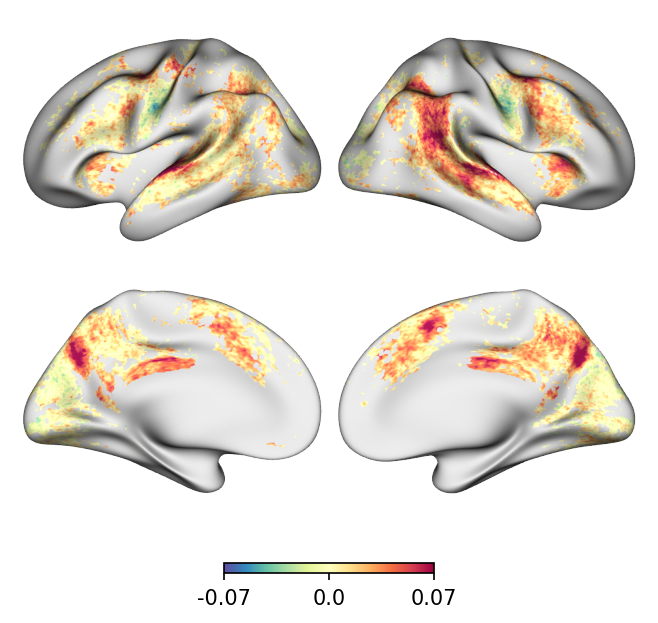

In [59]:
values = weight_sim_between.mean(0)

fig = plot.surface_plot(values, threshold=~enc_sigmask, cmap="Spectral_r")

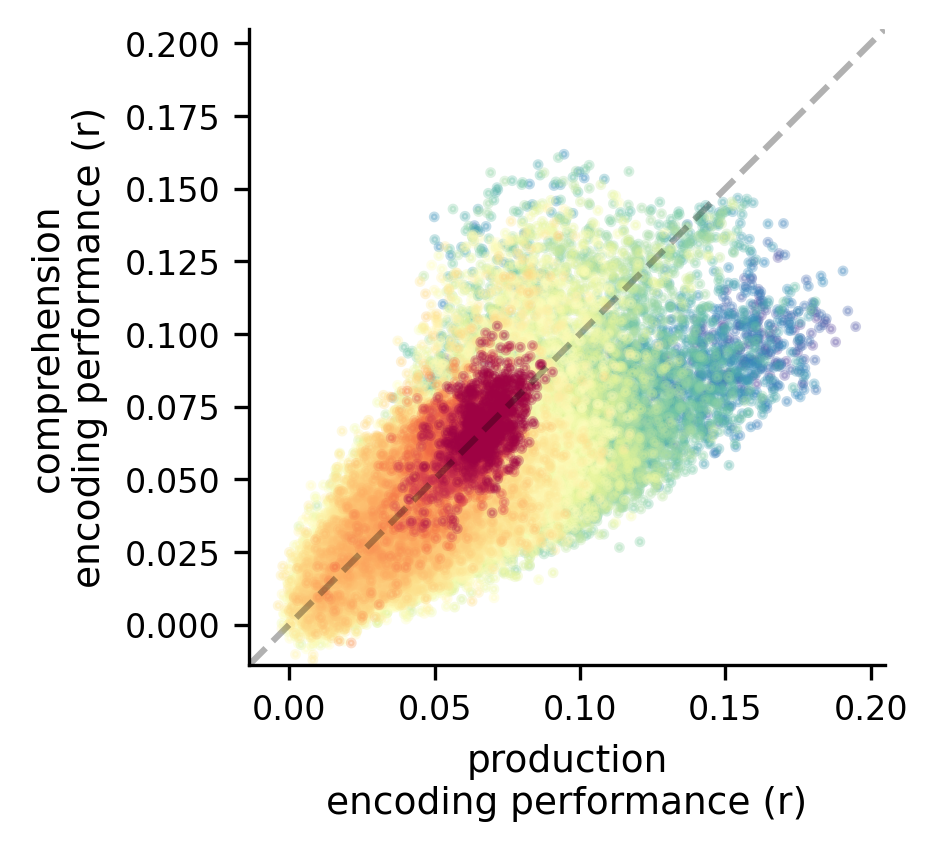

In [47]:
values1 = prod_scores
values2 = comp_scores

vox_colors  = weight_sim_between.mean(0)

order = vox_colors.argsort()[::-1]

fig = plt.figure(figsize=(2.75, 2.75), dpi=300)
ax = fig.add_subplot()

# ax.axvline(0, c="k", zorder=1, alpha=1)
# ax.axhline(0, c="k", zorder=1, alpha=1)
ax.axline(xy1=(0, 0), slope=1, alpha=0.3, c="k", ls='dashed')

im = ax.scatter(
    values1[order], values2[order], c=vox_colors[order], s=10, alpha=0.3,
    # edgecolors='black', linewidths=0.25, marker='o',
    marker='.',
    cmap='Spectral', vmin=-.1, vmax=0.1)
ax.set_aspect("equal", "box")

lim = max(ax.get_xlim()[1], ax.get_ylim()[1])
ax.set_xlim(ax.get_xlim()[0], lim)
ax.set_ylim(ax.get_xlim()[0], lim)

ax.set_xlabel("production\nencoding performance (r)")
ax.set_ylabel("comprehension\nencoding performance (r)")

# cbar = fig.colorbar(im, shrink=0.86)
# cbar.set_label("density")

# cbar = fig.colorbar(im, ax=ax)

# sns.despine(fig, left=True, bottom=True)

fig.show()

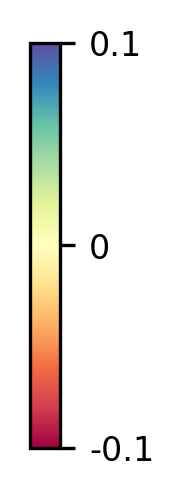

In [11]:
fig = plot.standalone_colorbar('Spectral', ticks=(0, 0.5, 1), tick_labels=(-.1, 0, .1), orientation='v')
fig.show()

# visualizing

In [65]:
subA = 104

In [114]:
# load subA preds
encpath = Path(root=encmodel, sub=f"{subA:03d}", datatype=modelname, ext=".hdf5")
with h5py.File(encpath, "r") as f:
    prod_predA = f["cv_preds"][:, -2]  # (5, 6, 240, 81924)
    comp_predA = f["cv_preds"][:, -1]
    prodmaskA = f["cv_prodmask"][...]

# load subB preds
subB = subject.get_partner(subA)
encpath = Path(root=encmodel, sub=f"{subB:03d}", datatype=modelname, ext=".hdf5")
with h5py.File(encpath, "r") as f:
    nuis_predsB = f["cv_preds"][:, :-2].sum(1)#.reshape(1200, -1)

dataB = subject.get_bold(subB, use_cache=True, cache_desc=cache)
# resB = dataB.reshape(5, 240, -1)
resB = dataB.reshape(5, 240, -1) - nuis_predsB
# resB = (dataB - zscore(nuis_predsB.reshape(1200, -1))).reshape(5, 240, -1)

compmaskA = ~prodmaskA

prod_predA.shape, comp_predA.shape, prodmaskA.shape, nuis_predsB.shape, resB.shape

((5, 240, 81924), (5, 240, 81924), (5, 240), (5, 240, 81924), (5, 240, 81924))

In [115]:
per_run = []
for i in range(5):
    per_run.append(correlation_score(prod_predA[i][prodmaskA[i]], resB[i][prodmaskA[i]]))
per_run = np.stack(per_run).mean(0)

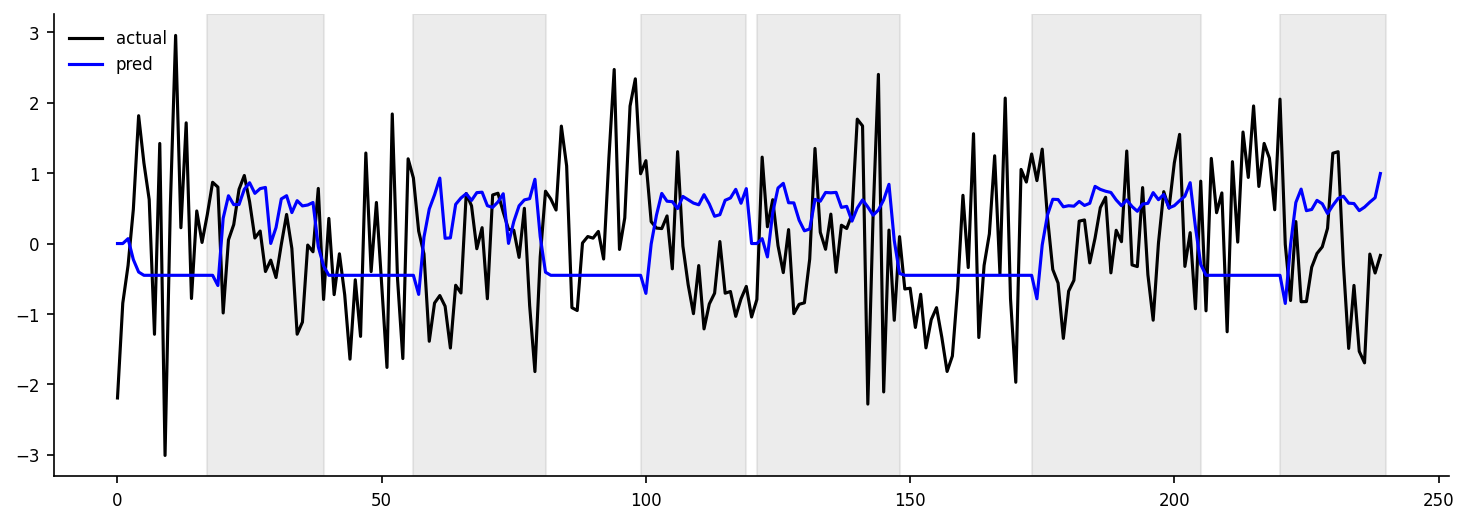

In [116]:
vox = 70117

fig, ax = plt.subplots(figsize=(12, 4))

switches = [0] + np.nonzero(np.diff(prodmaskA[0]))[0].tolist() + [240]
for i in range(1, len(switches)):
    if i % 2 == 0:
        ax.axvspan(switches[i - 1], switches[i], color="gray", alpha=0.15, zorder=1)
# ax.plot(prodmaskA[0], c='k')

plt.plot(resB[0, :, vox], label='actual', c='k')
plt.plot(prod_predA[0, :, vox], label='pred', c='b')

ax.legend()
fig.show()

# pseudo-dyads

In [4]:
from scipy.spatial.distance import cdist, pdist, squareform
import pandas as pd

In [5]:
catlas = Atlas.load("custom_glasser_group")
len(catlas)

22

In [6]:
encmodel, modelname, cache

('encoding_default_task', 'joint_split', 'default_task')

In [7]:
preds = []
actuals = []

for subA in tqdm(SUBS_STRANGERS):
    data = subject.get_bold(subA, cache=cache)
    actuals.append(catlas.vox_to_parc(data))

    encpath = Path(root='results/' + encmodel, sub=f"{subA:03d}", datatype=modelname, ext=".hdf5")
    with h5py.File(encpath, "r") as f:
        cv_predsA = f["cv_preds"][:, -1].reshape(1200, -1)
    preds.append(catlas.vox_to_parc(cv_predsA))

all_preds = np.stack(preds)
all_actuals = np.stack(actuals)
all_preds.shape, all_actuals.shape

  0%|          | 0/58 [00:00<?, ?it/s]

100%|██████████| 58/58 [01:30<00:00,  1.57s/it]


((58, 1200, 22), (58, 1200, 22))

In [50]:
dists = []
for roi in range(len(catlas)):
    preds1 = all_preds[:, :, roi]
    actuals1 = all_actuals[:, :, roi]
    c = cdist(preds1, actuals1, metric='correlation')  # MBC
    # c = squareform(pdist(actuals1, metric='correlation'))  # ISC
    dists.append(c)
dists = np.stack(dists)
dists.shape

(22, 58, 58)

In [22]:
enc, mbc, pseudos = [], [], []
for i, subA in enumerate(SUBS_STRANGERS):
    subB = subject.get_partner(subA) 
    j = SUBS_STRANGERS.index(subB)
    self = dists[:, i, i]
    partner = dists[:, i, j]
    others = dists[:, i, np.array([k for k in range(len(SUBS_STRANGERS)) if k != i and k != j])].mean(1)  # NOTE average
    # print(subA, subB, i, j, self.shape, partner.shape, others.shape)
    enc.append(self)
    mbc.append(partner)
    pseudos.append(others)
enc = 1 - np.stack(enc)
mbc = 1 - np.stack(mbc)
pseudos = 1 - np.stack(pseudos)
enc.shape, mbc.shape, pseudos.shape

((58, 22), (58, 22), (58, 22))

In [23]:
df = pd.DataFrame([enc.mean(0), mbc.mean(0), pseudos.mean(0)], index=['within', 'partner', 'pseudos']).T
df.index = catlas.labels
df

,within,partner,pseudos
LH_EAC,1.0,0.043396,0.018690
LH_pSTG,1.0,0.047620,0.036207
LH_aSTG,1.0,0.031373,0.019182
LH_IFG,1.0,0.006686,0.010090
LH_FOP,1.0,0.064241,0.038190
LH_MFG,1.0,0.091227,0.059418
LH_SM,1.0,0.060264,0.031627
LH_SMA,1.0,0.042034,0.032391
LH_IPS,1.0,0.079341,0.051424
LH_TPJ,1.0,0.007045,0.008049


In [24]:
avg_enc = np.stack(enc).mean(0)
avg_mbc = np.stack(mbc).mean(0)
avg_pseudos = np.stack(pseudos).mean(0)
avg_enc.shape, avg_mbc.shape, avg_pseudos.shape

((22,), (22,), (22,))

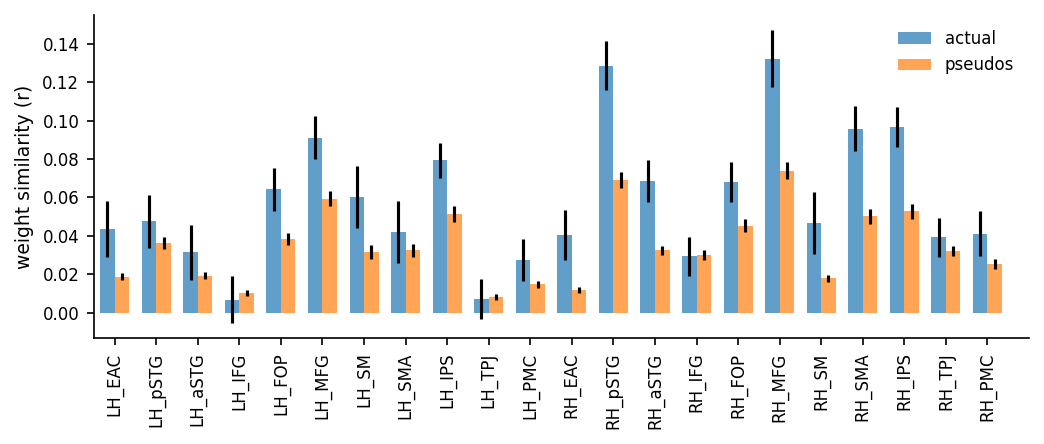

In [27]:
# Each column in mbc and pseudos is a region (ROI), each row is a subject
# We'll plot mean and std for each region

mbc_mean = mbc.mean(axis=0)
mbc_std = mbc.std(axis=0) / np.sqrt(mbc.shape[0])  # standard error
pseudos_mean = pseudos.mean(axis=0)
pseudos_std = pseudos.std(axis=0) / np.sqrt(pseudos.shape[0])  # standard error

labels = catlas.labels
x = np.arange(len(labels))  # the label locations
width = 0.35  # width of the bars

fig, ax = plt.subplots(figsize=(7, 3))
rects1 = ax.bar(x - width/2, mbc_mean, width, yerr=mbc_std, label='actual', alpha=0.7)
rects2 = ax.bar(x + width/2, pseudos_mean, width, yerr=pseudos_std, label='pseudos', alpha=0.7)

# ax.set_ylabel('ISC (r)')
ax.set_ylabel('weight similarity (r)')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=90)
ax.set_xlim(-0.5, 22)
ax.legend()

fig.tight_layout()
fig.show() 

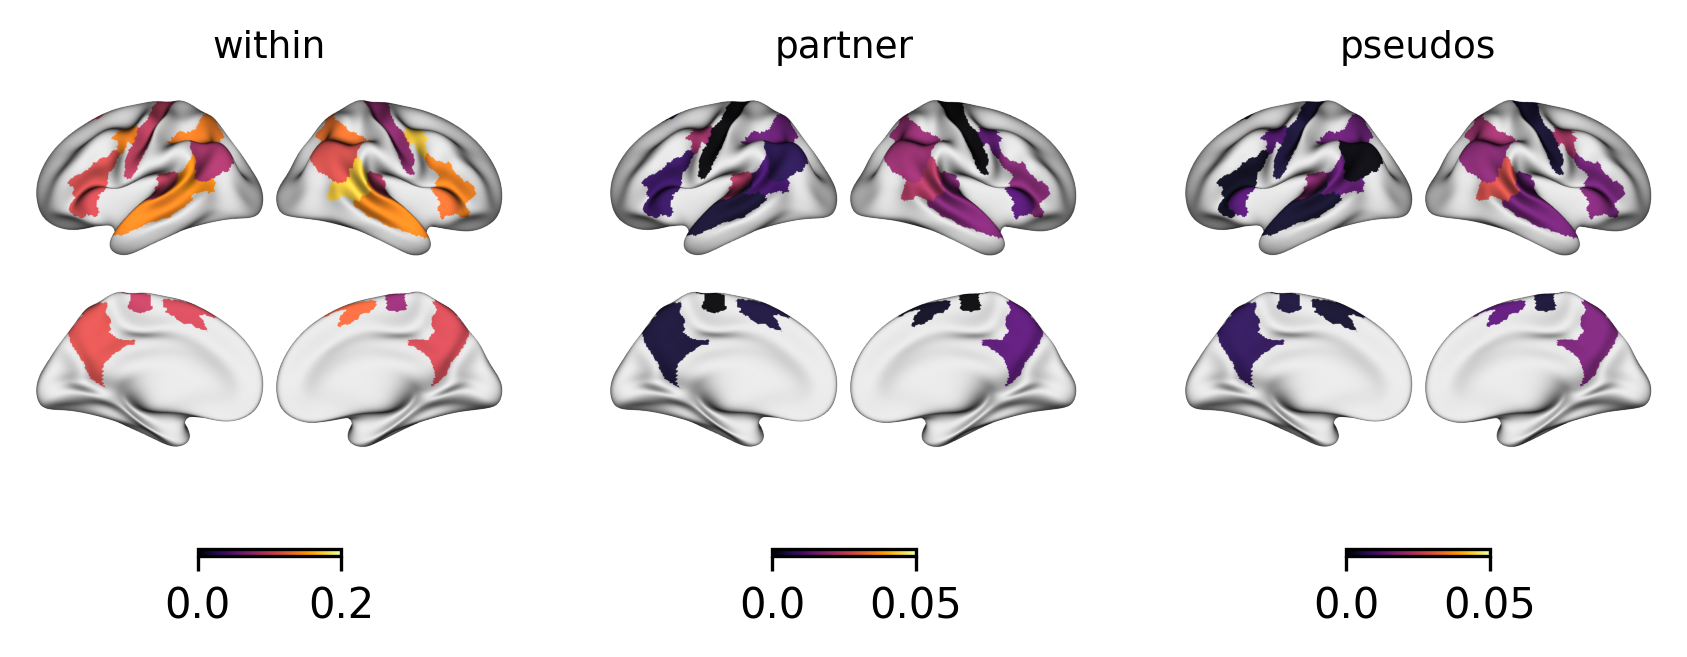

In [152]:
avg_enc_vox = catlas.parc_to_vox(avg_enc)
avg_mbc_vox = catlas.parc_to_vox(avg_mbc)
avg_pseudos_vox = catlas.parc_to_vox(avg_pseudos)

fig, axes = plt.subplots(1, 3, figsize=(7, 4.5), dpi=300)
plot.surface_plot(avg_enc_vox, fig=fig, ax=axes[0], vmin=0, vmax=.2, cmap="inferno", title='within')
plot.surface_plot(avg_mbc_vox, fig=fig, ax=axes[1], vmin=0, vmax=.05, cmap="inferno", title='partner')
plot.surface_plot(avg_pseudos_vox, fig=fig, ax=axes[2], vmin=0, vmax=.05, cmap="inferno", title='pseudos')
fig.show()

## weight similarity

In [6]:
encmodel, modelname

('encoding_default_task', 'joint_split')

In [9]:
%ls results/encoding_default_task_n2w/sub-104/joint_nosplit/

sub-104_desc-model-gpt2-2b_layer-24.hdf5


In [17]:
modelname = 'joint_nosplit'

# sim between prod and comp
weight_sim_between = []

respath = Path(
    root='results/' + encmodel + '_n2w',
    sub="000",
    desc="model-gpt2-2b_layer-24",
    datatype=modelname,
    ext=".hdf5",
)

weights = []
for i, sub in enumerate(tqdm(SUBS_STRANGERS)):
    respath.update(sub=f"{sub:03d}")
    with h5py.File(respath, "r") as f:
        # print(f['cv_preds'].shape, f.keys())
        llm_weights = f["cv_weights_comp"][...].squeeze()
        weights.append(catlas.vox_to_parc(llm_weights))


100%|██████████| 58/58 [00:38<00:00,  1.52it/s]


In [20]:
weights = np.stack(weights)

In [21]:
dists = []
for roi in range(len(catlas)):
    c = squareform(pdist(weights[:, :, roi], metric='correlation'))  # ISC
    dists.append(c)
dists = np.stack(dists)
dists.shape

(22, 58, 58)